# Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
def compute_disparity_dp(Il, Ir, sigma=2, c0=1):
    """
    Compute disparity maps using dynamic programming.
    
    Args:
        Il: Left grayscale image (H x W numpy array)
        Ir: Right grayscale image (H x W numpy array)
        sigma: Pixel noise measure (default 2)
        c0: Cost of skipping a pixel (default 1)
    
    Returns:
        disp_left:  Disparity map for the left image  (H x W)
        disp_right: Disparity map for the right image (H x W)
    """
    H, W = Il.shape
    disp_left  = np.zeros((H, W), dtype=np.float32)
    disp_right = np.zeros((H, W), dtype=np.float32)

    for row in range(H):
        scanline_l = Il[row].astype(np.float64)   # shape (W,)
        scanline_r = Ir[row].astype(np.float64)   # shape (W,)

        # ── 1. Build the N×N cost matrix d[i,j] ──────────────────────────
        # d[i,j] = (Il(i) - Ir(j))^2 / sigma^2
        diff = scanline_l[:, None] - scanline_r[None, :]   # (W, W)
        d = (diff ** 2) / (sigma ** 2)

        # ── 2. Fill the DP table D ────────────────────────────────────────
        N = W
        D = np.full((N, N), np.inf, dtype=np.float64)
        D[0, 0] = d[0, 0]

        # First row: can only arrive by skipping pixels in Il  (i stays 0)
        for j in range(1, N):
            D[0, j] = D[0, j-1] + c0

        # First column: can only arrive by skipping pixels in Ir (j stays 0)
        for i in range(1, N):
            D[i, 0] = D[i-1, 0] + c0

        # Fill the rest
        for i in range(1, N):
            for j in range(1, N):
                match = D[i-1, j-1] + d[i, j]   # match  Il(i) ↔ Ir(j)
                skip_l = D[i-1, j]  + c0          # skip pixel i in Il
                skip_r = D[i, j-1]  + c0          # skip pixel j in Ir
                D[i, j] = min(match, skip_l, skip_r)

        # ── 3. Backtrack from (N-1, N-1) to (0, 0) ───────────────────────
        disp_l_row = np.zeros(N, dtype=np.float32)
        disp_r_row = np.zeros(N, dtype=np.float32)

        i, j = N - 1, N - 1
        while i > 0 or j > 0:
            if i == 0:
                # Can only move left → skip pixel j in Ir
                disp_r_row[j] = 0
                j -= 1
            elif j == 0:
                # Can only move up → skip pixel i in Il
                disp_l_row[i] = 0
                i -= 1
            else:
                match  = D[i-1, j-1]
                skip_l = D[i-1, j]
                skip_r = D[i, j-1]
                best   = min(match, skip_l, skip_r)

                if best == match:
                    # Matched: disparity = |i - j|
                    disp_l_row[i] = abs(i - j)
                    disp_r_row[j] = abs(i - j)
                    i -= 1
                    j -= 1
                elif best == skip_l:
                    # Skip pixel i in Il → left disparity is 0
                    disp_l_row[i] = 0
                    i -= 1
                else:
                    # Skip pixel j in Ir → right disparity is 0
                    disp_r_row[j] = 0
                    j -= 1

        disp_left[row]  = disp_l_row
        disp_right[row] = disp_r_row

    return disp_left, disp_right

# Main

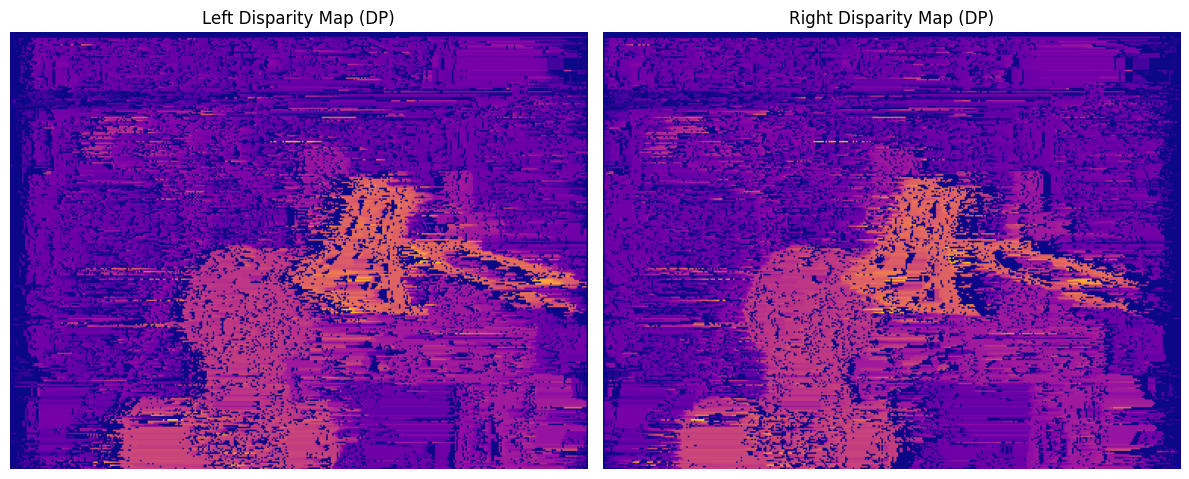

In [9]:
Il = np.array(Image.open("stereo_materials/l1.png").convert("L"), dtype=np.float32)
Ir = np.array(Image.open("stereo_materials/r1.png").convert("L"), dtype=np.float32)

disp_left, disp_right = compute_disparity_dp(Il, Ir, sigma=2, c0=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(disp_left,  cmap="plasma")
axes[0].set_title("Left Disparity Map (DP)")
axes[0].axis("off")
axes[1].imshow(disp_right, cmap="plasma")
axes[1].set_title("Right Disparity Map (DP)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("disparity_dp.png", dpi=150)
plt.show()

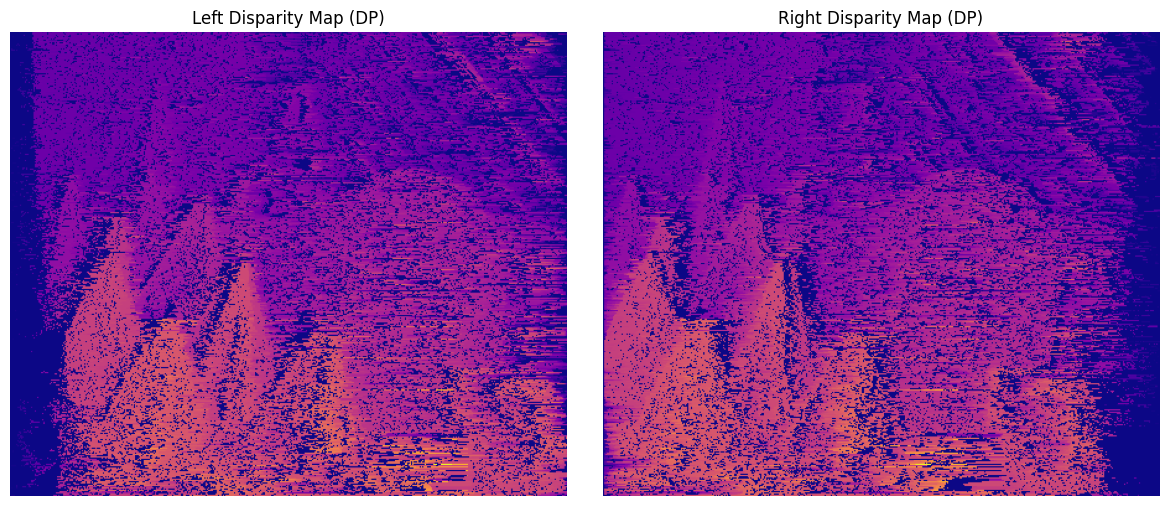

In [ ]:

# Load images (replace with your actual image paths)
Il = np.array(Image.open("stereo_materials/l2.png").convert("L"), dtype=np.float32)
Ir = np.array(Image.open("stereo_materials/r2.png").convert("L"), dtype=np.float32)

disp_left, disp_right = compute_disparity_dp(Il, Ir, sigma=2, c0=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(disp_left,  cmap="plasma")
axes[0].set_title("Left Disparity Map (DP)")
axes[0].axis("off")
axes[1].imshow(disp_right, cmap="plasma")
axes[1].set_title("Right Disparity Map (DP)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("disparity_dp.png", dpi=150)
plt.show()

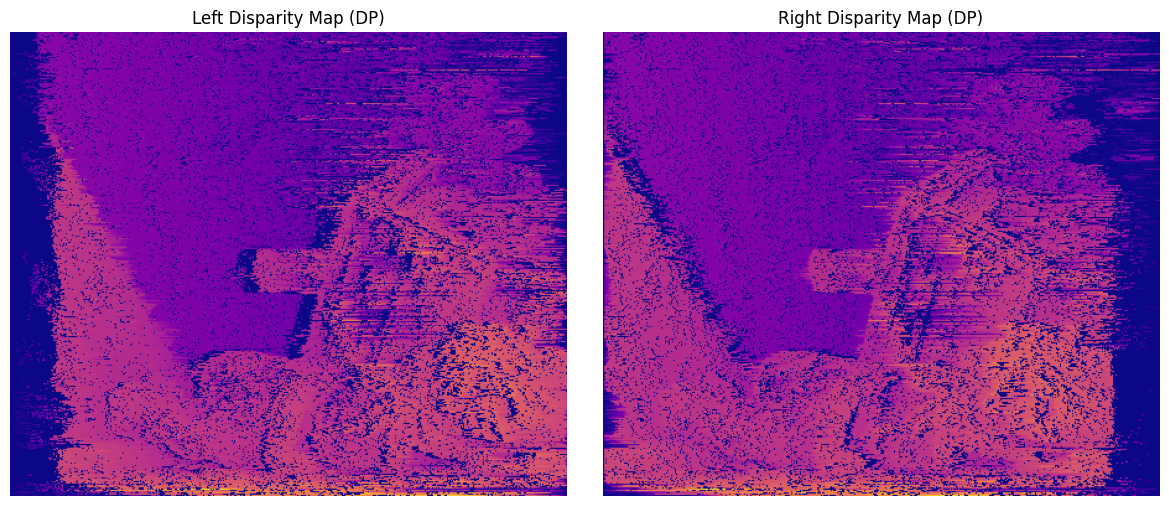

In [10]:
Il = np.array(Image.open("stereo_materials/l3.png").convert("L"), dtype=np.float32)
Ir = np.array(Image.open("stereo_materials/r3.png").convert("L"), dtype=np.float32)

disp_left, disp_right = compute_disparity_dp(Il, Ir, sigma=2, c0=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(disp_left,  cmap="plasma")
axes[0].set_title("Left Disparity Map (DP)")
axes[0].axis("off")
axes[1].imshow(disp_right, cmap="plasma")
axes[1].set_title("Right Disparity Map (DP)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("disparity_dp.png", dpi=150)
plt.show()